# Chapter 05 - Linear Models and Regularization
## Understanding Regression Models in scikit-learn
Based on scikit-learn Cookbook. This notebook explains linear regression, Ridge, and Lasso with practical examples and theory.

## Objective
Learn how linear models predict numeric targets and how regularization helps reduce overfitting.

## Theory Introduction
Linear Regression models the relationship between input features and a numeric target using a linear equation. It is one of the most fundamental supervised learning algorithms.

Regularization adds penalties to model coefficients to prevent overly complex models and improve generalization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
plt.style.use('ggplot')

## 1. Generate Regression Dataset

In [2]:
X, y = make_regression(n_samples=300, n_features=8, noise=25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

Synthetic regression data is created to simulate real-world prediction tasks.

## 2. Train Models

In [3]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.5)

models = {
    'Linear Regression': lr,
    'Ridge': ridge,
    'Lasso': lasso
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results[name] = {
        'RMSE': rmse,
        'R2': r2_score(y_test, pred)
    }

results

{'Linear Regression': {'RMSE': np.float64(23.27642464755924),
  'R2': 0.973294463020369},
 'Ridge': {'RMSE': np.float64(23.205196900212684), 'R2': 0.9734576551655749},
 'Lasso': {'RMSE': np.float64(23.315842853450178), 'R2': 0.9732039357403386}}

## 3. Performance Comparison

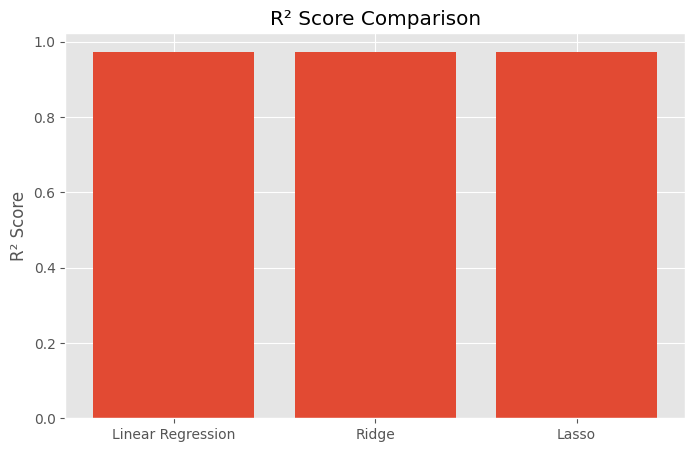

In [4]:
names = list(results.keys())
r2_vals = [results[n]['R2'] for n in names]
plt.figure(figsize=(8,5))
plt.bar(names, r2_vals)
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.show()

**Description:** Higher R² indicates the model explains more variance in the target variable. Regularized models may perform better on noisy data.

## 4. Coefficient Comparison

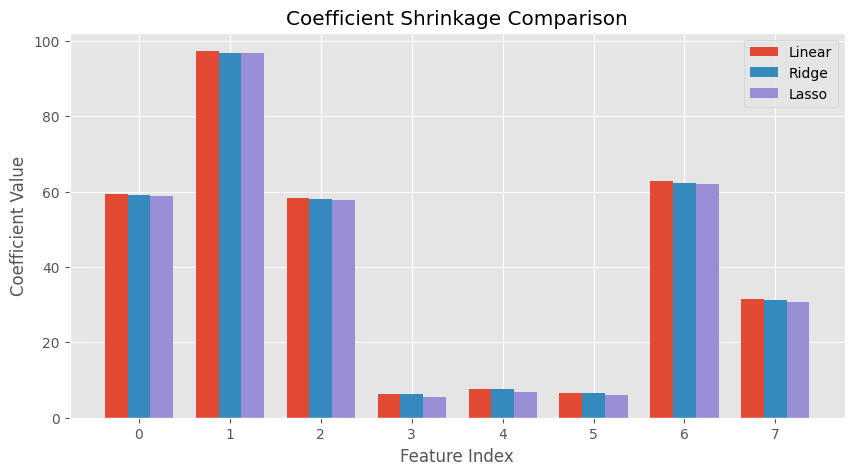

In [5]:
coef_lr = lr.coef_
coef_ridge = ridge.coef_
coef_lasso = lasso.coef_
idx = np.arange(len(coef_lr))
width = 0.25
plt.figure(figsize=(10,5))
plt.bar(idx-width, coef_lr, width, label='Linear')
plt.bar(idx, coef_ridge, width, label='Ridge')
plt.bar(idx+width, coef_lasso, width, label='Lasso')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Shrinkage Comparison')
plt.legend()
plt.show()

**Description:** Ridge shrinks coefficients smoothly, while Lasso can force some coefficients close to zero, helping feature selection.

## 5. Actual vs Predicted (Linear Regression)

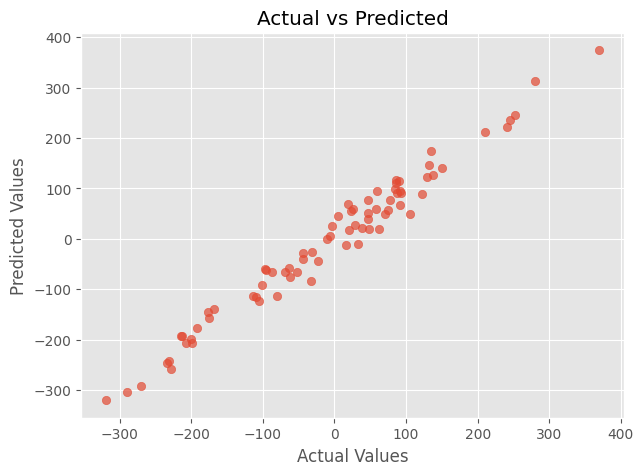

In [6]:
pred_lr = lr.predict(X_test)
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_lr, alpha=0.7)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

**Description:** Points close to a diagonal relationship indicate accurate predictions.

## Important Theory Concepts
- **Overfitting:** Model memorizes noise instead of learning patterns.
- **Regularization:** Penalizes large coefficients.
- **Ridge (L2):** Shrinks all coefficients.
- **Lasso (L1):** Shrinks and can eliminate some coefficients.
- **Multicollinearity:** Strong correlation among features can destabilize coefficients.

## Interpretation of Results
If Ridge or Lasso performs similarly or better than standard Linear Regression, it suggests regularization improved generalization.

## Summary
Linear models are fast, interpretable, and effective baselines. Regularization methods such as Ridge and Lasso are valuable when dealing with noisy data or many correlated features.

## Conclusion
For practical machine learning tasks, always compare Linear Regression with Ridge and Lasso to balance simplicity and predictive performance.